In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import linear_kernel
import joblib
import faiss
from sklearn.feature_extraction.text import TfidfTransformer

In [4]:
basics = pd.read_csv("title.basics.tsv", sep="\t")
ratings = pd.read_csv("title.ratings.tsv", sep="\t")

In [5]:
basics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


In [6]:
ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2209
1,tt0000002,5.5,315
2,tt0000003,6.4,2320
3,tt0000004,5.1,198
4,tt0000005,6.2,3046


In [7]:
# Combine both datasets on ratings
full_set = basics.merge(ratings, on="tconst", how="left")


In [8]:
old_set = basics.merge(ratings, on="tconst", how="left")

In [9]:
old_set.dtypes

tconst                str
titleType             str
primaryTitle          str
originalTitle         str
isAdult             int64
startYear             str
endYear               str
runtimeMinutes        str
genres                str
averageRating     float64
numVotes          float64
dtype: object

In [10]:
old_set.isna().sum()

tconst                   0
titleType                0
primaryTitle            25
originalTitle           25
isAdult                  0
startYear                0
endYear                  0
runtimeMinutes           0
genres                 487
averageRating     10790361
numVotes          10790361
dtype: int64

In [11]:
def breakdown(data):
    data_frames = {}
    for item in data.titleType.unique():
        data_frames[item] = data[data["titleType"] == item]
    return data_frames

In [12]:
old_types = breakdown(full_set)

In [13]:
old_types.keys()

dict_keys(['short', 'movie', 'tvShort', 'tvSeries', 'tvMovie', 'tvEpisode', 'tvMiniSeries', 'tvSpecial', 'video', 'videoGame', 'tvPilot'])

In [14]:
def counts_per_type(vals):
    numbers = {}
    for element in vals:
        numbers[element] = len(vals[element])
    return numbers

In [15]:
print(counts_per_type(old_types))

{'short': 1126721, 'movie': 744043, 'tvShort': 10984, 'tvSeries': 298325, 'tvMovie': 154639, 'tvEpisode': 9618581, 'tvMiniSeries': 69735, 'tvSpecial': 57803, 'video': 324784, 'videoGame': 48801, 'tvPilot': 1}


In [16]:
len(full_set)

12454417

In [17]:
# number of null values per dataset

def nulls_per_type(elements):
    results = {}
    for element in elements:
        results[element] = elements[element].isnull().sum()
    return results

In [18]:
print(nulls_per_type(old_types))

{'short': tconst                 0
titleType              0
primaryTitle           5
originalTitle          5
isAdult                0
startYear              0
endYear                0
runtimeMinutes         0
genres                 0
averageRating     945884
numVotes          945884
dtype: int64, 'movie': tconst                 0
titleType              0
primaryTitle           3
originalTitle          3
isAdult                0
startYear              0
endYear                0
runtimeMinutes         0
genres                 0
averageRating     401321
numVotes          401321
dtype: int64, 'tvShort': tconst               0
titleType            0
primaryTitle         0
originalTitle        0
isAdult              0
startYear            0
endYear              0
runtimeMinutes       0
genres               0
averageRating     8420
numVotes          8420
dtype: int64, 'tvSeries': tconst                 0
titleType              0
primaryTitle           1
originalTitle          1
isAdult      

In [19]:
#get the number of types without ratings vs the number of ratings
def has_ratings(elements):
    results = {}
    for element in elements:
        results[element] = {'len' : len(elements[element]), 'noRatings': int(elements[element]['averageRating'].isnull().sum()), 'noVotes' : int(elements[element]['numVotes'].isnull().sum())}
    return results

In [20]:
has_ratings(old_types)

{'short': {'len': 1126721, 'noRatings': 945884, 'noVotes': 945884},
 'movie': {'len': 744043, 'noRatings': 401321, 'noVotes': 401321},
 'tvShort': {'len': 10984, 'noRatings': 8420, 'noVotes': 8420},
 'tvSeries': {'len': 298325, 'noRatings': 187126, 'noVotes': 187126},
 'tvMovie': {'len': 154639, 'noRatings': 98082, 'noVotes': 98082},
 'tvEpisode': {'len': 9618581, 'noRatings': 8764671, 'noVotes': 8764671},
 'tvMiniSeries': {'len': 69735, 'noRatings': 44919, 'noVotes': 44919},
 'tvSpecial': {'len': 57803, 'noRatings': 43789, 'noVotes': 43789},
 'video': {'len': 324784, 'noRatings': 266991, 'noVotes': 266991},
 'videoGame': {'len': 48801, 'noRatings': 29157, 'noVotes': 29157},
 'tvPilot': {'len': 1, 'noRatings': 1, 'noVotes': 1}}

In [21]:
results = has_ratings(old_types)

In [22]:
results

{'short': {'len': 1126721, 'noRatings': 945884, 'noVotes': 945884},
 'movie': {'len': 744043, 'noRatings': 401321, 'noVotes': 401321},
 'tvShort': {'len': 10984, 'noRatings': 8420, 'noVotes': 8420},
 'tvSeries': {'len': 298325, 'noRatings': 187126, 'noVotes': 187126},
 'tvMovie': {'len': 154639, 'noRatings': 98082, 'noVotes': 98082},
 'tvEpisode': {'len': 9618581, 'noRatings': 8764671, 'noVotes': 8764671},
 'tvMiniSeries': {'len': 69735, 'noRatings': 44919, 'noVotes': 44919},
 'tvSpecial': {'len': 57803, 'noRatings': 43789, 'noVotes': 43789},
 'video': {'len': 324784, 'noRatings': 266991, 'noVotes': 266991},
 'videoGame': {'len': 48801, 'noRatings': 29157, 'noVotes': 29157},
 'tvPilot': {'len': 1, 'noRatings': 1, 'noVotes': 1}}

In [ ]:
def plot_per_type_nulls(type_name, stats_dict):
    # Extract values from the nested dictionary
    count = stats_dict['len']
    no_ratings = stats_dict['noRatings'] 
    no_votes = stats_dict['noVotes'] 

    labels = ['Total Count', 'No Ratings', 'No Votes'] 
    values = [count, no_ratings, no_votes] 
    
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, values, color=['#3498db', '#e67e22', '#2ecc71'])
    
    ax.set_ylabel("Number of Items")
    ax.set_title(f"Statistics for: {type_name}", fontsize=14, fontweight='bold')
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:,}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


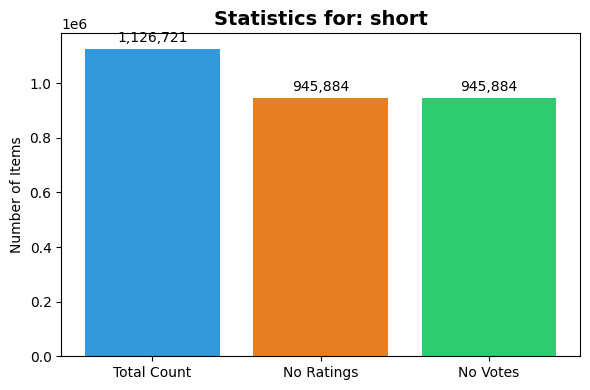

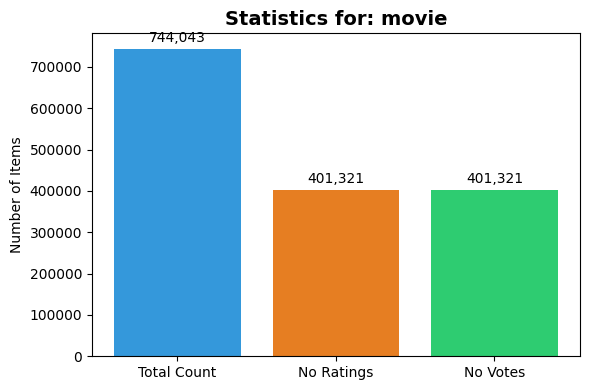

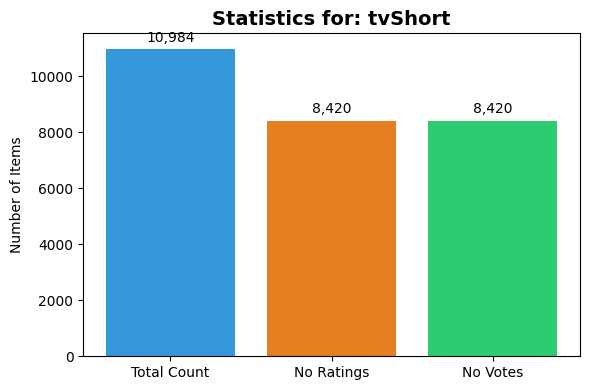

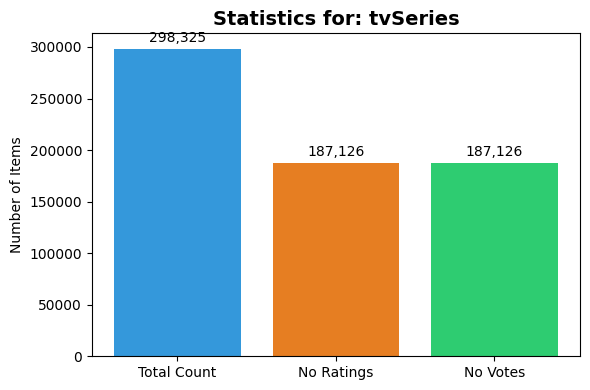

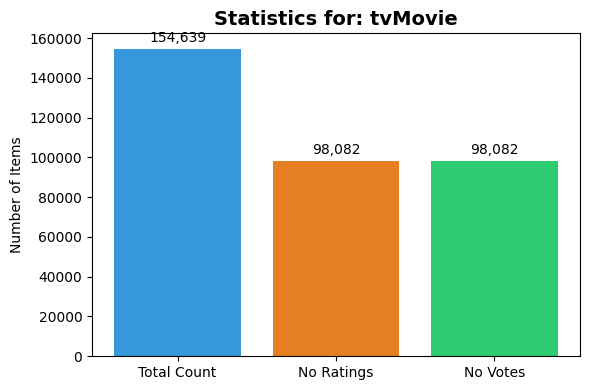

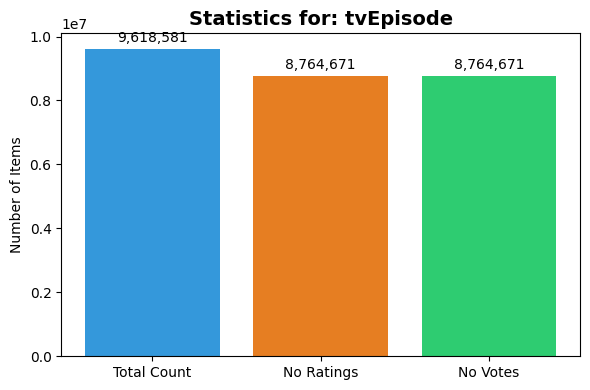

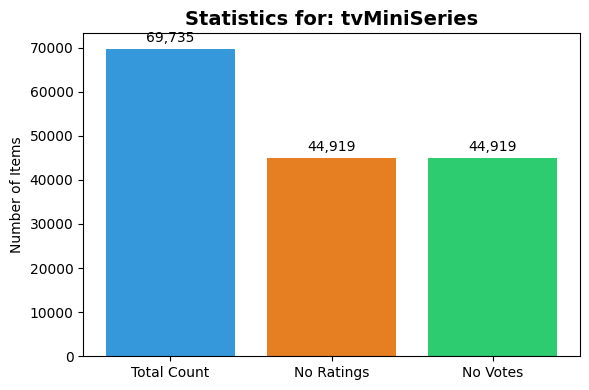

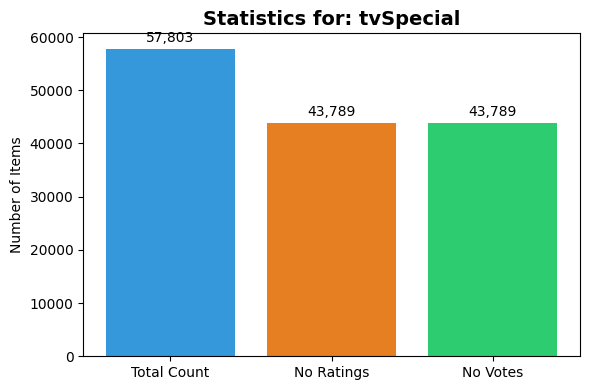

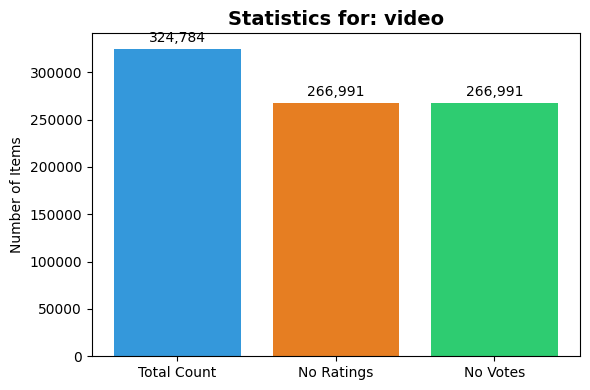

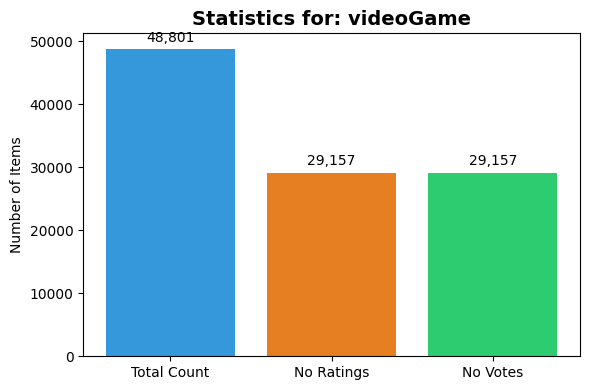

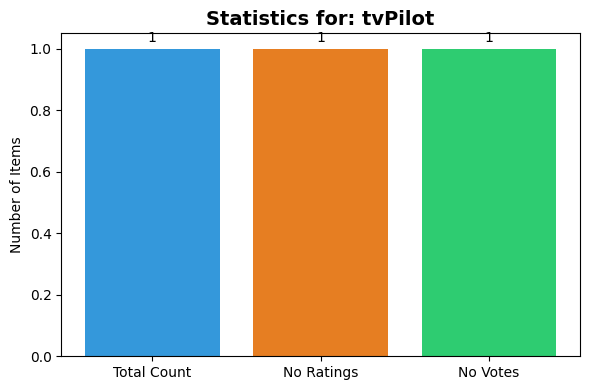

In [24]:
for element in results: 
    plot_per_type_nulls(element, results[element])

In [25]:
full_set.dtypes

tconst                str
titleType             str
primaryTitle          str
originalTitle         str
isAdult             int64
startYear             str
endYear               str
runtimeMinutes        str
genres                str
averageRating     float64
numVotes          float64
dtype: object

In [26]:
basics.isnull().sum()

tconst              0
titleType           0
primaryTitle       25
originalTitle      25
isAdult             0
startYear           0
endYear             0
runtimeMinutes      0
genres            487
dtype: int64

In [27]:
#to avoid losing the genre in the one hot encoded version, make the genre blank, we can use the rating and dataset values to continue using it effectively
full_set["genres"] = full_set["genres"].fillna("")

In [28]:
#drop the other null values without primary titles - its hard to recommend a movie without a title

full_set = full_set.dropna(subset=["primaryTitle", "originalTitle"])


In [29]:
#one hot encoding of all genres from the dataset by separating all genres from strings and using get dummies  to clean them up.and one hot encode them.
with_genres = (
    full_set["genres"]
    .str.get_dummies(sep=",")
    .set_axis(full_set.index)
)

In [30]:
full_set = pd.concat([full_set, with_genres], axis=1)

In [31]:
print(full_set.index.equals(with_genres.index))

True


In [32]:
full_set.columns

Index(['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult',
       'startYear', 'endYear', 'runtimeMinutes', 'genres', 'averageRating',
       'numVotes', 'Action', 'Adult', 'Adventure', 'Animation', 'Biography',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
       'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical',
       'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport',
       'Talk-Show', 'Thriller', 'War', 'Western', '\N'],
      dtype='str')

In [33]:
full_set = full_set.loc[:, full_set.columns != "\\N"]

In [34]:
full_set.dtypes

tconst                str
titleType             str
primaryTitle          str
originalTitle         str
isAdult             int64
startYear             str
endYear               str
runtimeMinutes        str
genres                str
averageRating     float64
numVotes          float64
Action              int64
Adult               int64
Adventure           int64
Animation           int64
Biography           int64
Comedy              int64
Crime               int64
Documentary         int64
Drama               int64
Family              int64
Fantasy             int64
Film-Noir           int64
Game-Show           int64
History             int64
Horror              int64
Music               int64
Musical             int64
Mystery             int64
News                int64
Reality-TV          int64
Romance             int64
Sci-Fi              int64
Short               int64
Sport               int64
Talk-Show           int64
Thriller            int64
War                 int64
Western     

In [35]:
def plot_balance(classes, counts):
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(classes, counts)
    ax.bar_label(bars, fmt='{:,.0f}', padding=0.3)
    ax.set_title("Class Distribution")
    ax.set_xlabel("Type")
    ax.set_ylabel("Count")
    ax.spines['top'].set_visible(False)
    fig.autofmt_xdate()
    plt.tight_layout()

In [36]:
def plot_class_distribution(data): 
    counter = has_ratings(data)
    
    # 1. Sort the items by the 'len' value inside the sub-dictionary
    sorted_items = sorted(counter.items(), key=lambda item: item[1]['len'], reverse=True)
    
    # 2. Extract the sorted keys and sorted lengths
    cls = [item[0] for item in sorted_items]
    cts = [item[1]['len'] for item in sorted_items]

    plot_balance(cls, cts)

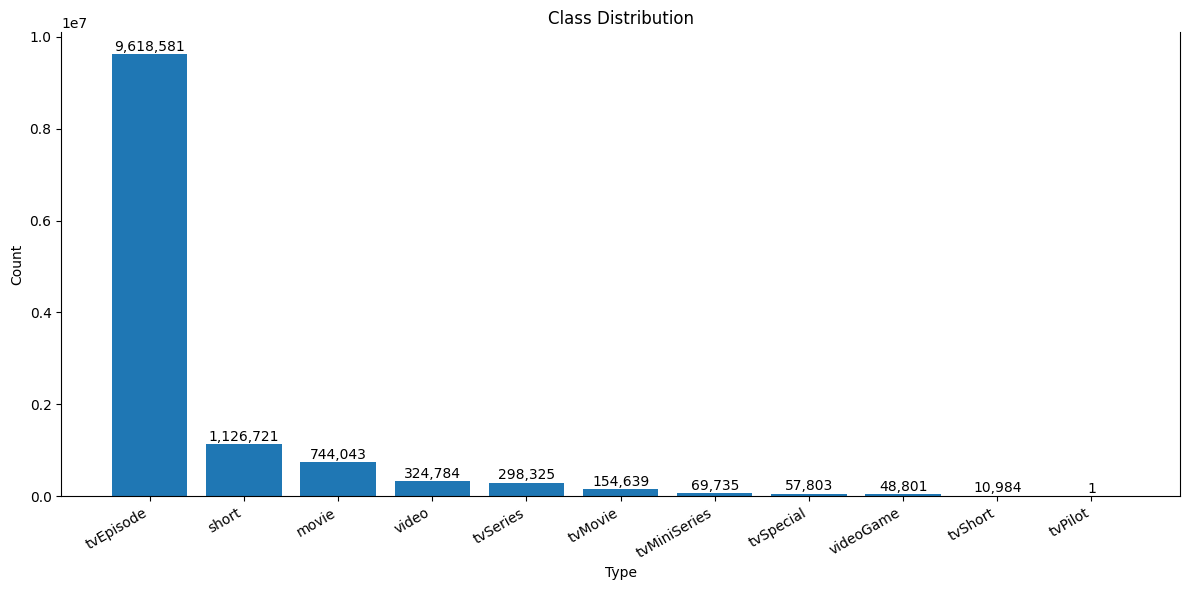

In [37]:
plot_class_distribution(old_types)

In [38]:
# 1. Clean Numeric Columns (Handling the "\N" or strings in IMDb data)
full_set['startYear'] = pd.to_numeric(full_set['startYear'], errors='coerce')
full_set['averageRating'] = pd.to_numeric(full_set['averageRating'], errors='coerce')


In [39]:
# Fill NaNs so the scaler doesn't crash (using median is safer than 0)
full_set['startYear'] = full_set['startYear'].fillna(full_set['startYear'].median())
full_set['averageRating'] = full_set['averageRating'].fillna(full_set['averageRating'].median())

# 2. Apply Log Transform to Votes
full_set['log_numVotes'] = np.log1p(full_set['numVotes'].fillna(0))

# 3. Scaling all numerical features to [0, 1]
scaler = MinMaxScaler()
# We scale Year, Log Votes, and Average Rating
num_features = ['startYear', 'log_numVotes', 'averageRating']
full_set[['scaled_year', 'scaled_votes', 'scaled_rating']] = scaler.fit_transform(full_set[num_features])

In [40]:
# 4. Feature Selection & Weighting
# Optional: Multiply the numerical features by a weight (e.g., 0.5) 
# if you want Genres to be more important than Year/Rating.

genre_cols = full_set.columns[full_set.columns.get_loc("Action"):]
weight = 1.0 
full_set['scaled_year'] *= weight
full_set['scaled_votes'] *= weight
full_set['scaled_rating'] *= weight

# 5. Final Inference Matrix
feature_cols = list(genre_cols) + ['scaled_year', 'scaled_votes', 'scaled_rating']
inference_matrix = full_set[feature_cols].values

In [41]:
# Filter for only what you need
keep_types = ['movie', 'tvSeries', 'short', 'tvMovie', 'tvMiniSeries', 'tvShort']
filtered_set = full_set[full_set["titleType"].isin(keep_types)]

In [42]:
types = breakdown(filtered_set)

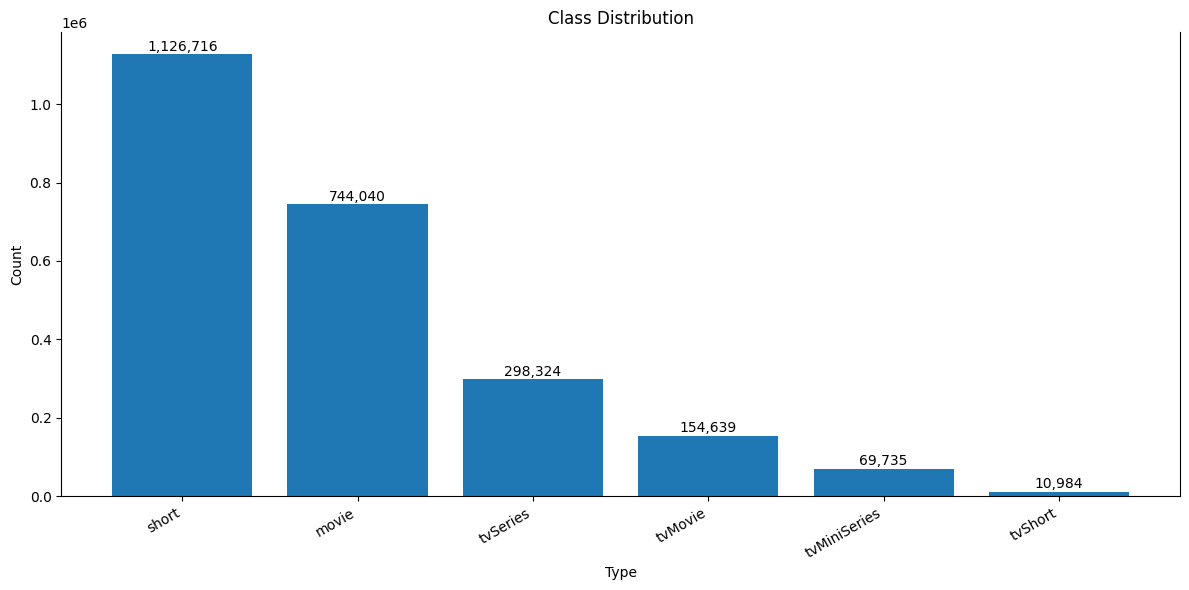

In [43]:
plot_class_distribution(types)

In [44]:
def plot_features(data): 
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(data, bins=30)
    ax.title("Feature Distribution")
    ax.xlabel("Value")
    ax.ylabel("Frequency")
    fig.autofmt_xdate()
    plt.tight_layout()

In [45]:
def plot_genre_distribution(df):
    # 1. Identify the genre columns (binary columns from Action to Western)
    genre_cols = df.columns[df.columns.get_loc("Action"):]
    
    # 2. Sum the counts for each genre and sort ascending
    genre_counts = df[genre_cols].sum().sort_values(ascending=True)
    
    # 3. Plotting
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Use barh (horizontal bar) for better readability of many genres
    ax.barh(genre_counts.index, genre_counts.values, color='#3F888F', edgecolor='black')
    
    ax.set_title("Distribution of Movie Genres", fontsize=15)
    ax.set_xlabel("Number of Movies")
    ax.set_ylabel("Genre")
    
    plt.tight_layout()
    plt.show()

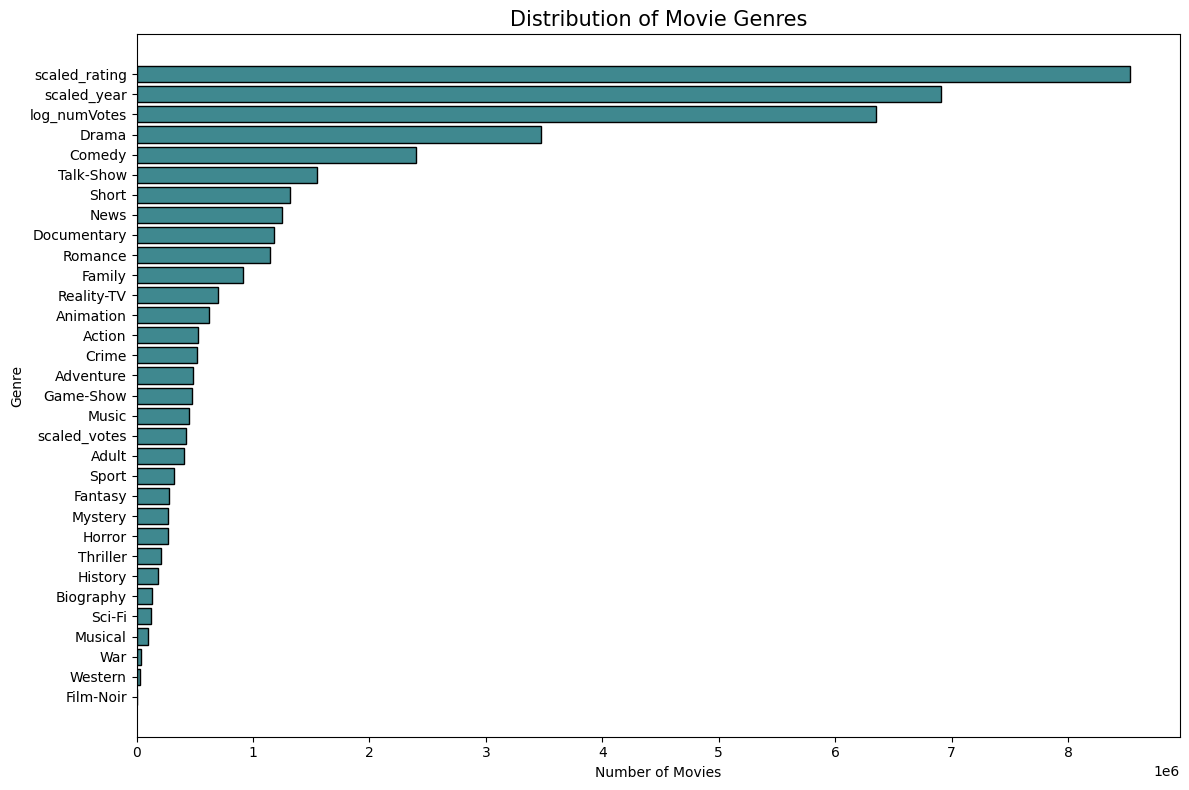

In [46]:
plot_genre_distribution(full_set)

In [ ]:
def train_faiss_optimized(df, feature_columns):
    # --- CRITICAL PRE-PROCESSING ---
    print("Step 0: Aligning Data...")
    # 1. Sort by popularity so 'Inception' (2010) is above 'Inception' (2014)
    df = df.sort_values('numVotes', ascending=False)
    # 2. Reset index so Row 0 is the most popular movie, Row 1 is next, etc.
    # This ensures df.index perfectly matches the FAISS vector IDs
    df = df.reset_index(drop=True)
    
    print("Step 1: TF-IDF Transformation...")
    tfidf = TfidfTransformer()
    sparse_matrix = tfidf.fit_transform(df[feature_columns])
    
    # Step 2: Initialize FAISS Index
    d = sparse_matrix.shape[1]
    index = faiss.IndexFlatIP(d)
    
    # Step 3 & 4: Batch Processing (Perfect for your 16GB RAM)
    batch_size = 100000 
    total_rows = sparse_matrix.shape[0]
    
    print(f"Step 4: Adding {total_rows} rows to index...")
    for i in range(0, total_rows, batch_size):
        end = min(i + batch_size, total_rows)
        batch_dense = sparse_matrix[i:end].toarray().astype('float32')
        faiss.normalize_L2(batch_dense)
        index.add(batch_dense)
        if i % 1000000 == 0:
            print(f"Processed {i} rows...")

    # Step 5: Save Assets
    print("Step 6: Saving model assets...")
    faiss.write_index(index, "movie_faiss.index")

    # The mapping now uses the RESET index (0, 1, 2...)
    # drop_duplicates(keep='first') ensures we keep the most popular version of a title
    indices_map = pd.Series(df.index, index=df['primaryTitle']).drop_duplicates(keep='first')
    
    joblib.dump(indices_map, "indices_map.pkl")
    
    meta_cols = ['primaryTitle', 'startYear', 'genres', 'averageRating', 'numVotes', 'titleType']
    joblib.dump(df[meta_cols], "metadata.pkl")
    
    print("Done! Alignment verified.")
    return index

In [186]:
index = train_faiss_optimized(filtered_set, feature_cols)

Step 0: Aligning Data...
Step 1: TF-IDF Transformation...
Step 4: Adding 2404438 rows to index...
Processed 0 rows...
Processed 1000000 rows...
Processed 2000000 rows...
Step 6: Saving model assets...
Done! Alignment verified.


In [220]:
import re

def professional_title_case(text):
    # List of words to keep lowercase (articles, conjunctions, short prepositions)
    lowercase_exceptions = {'a', 'an', 'and', 'as', 'at', 'but', 'by', 'for', 
                            'if', 'in', 'is', 'nor', 'of', 'on', 'or', 'so', 
                            'the', 'to', 'up', 'yet', 'it'}
    
    def replace_func(match):
        word = match.group(0)
        # Always capitalize the first word, otherwise check the exception list
        if match.start() == 0:
            return word.capitalize()
        
        return word.lower() if word.lower() in lowercase_exceptions else word.capitalize()

    # Regex: \w+ looks for sequences of alphanumeric characters
    return re.sub(r'[\w\']+', replace_func, text)

# Test cases
print(professional_title_case("this is a test of the regex"))
# Output: This is a Test of the Regex

print(professional_title_case("is it working?"))
# Output: Is it Working? (Capitalized because it's the first word)

This is a Test of the Regex
Is it Working?


In [ ]:
indices_map = joblib.load('indices_map.pkl')
metadata = joblib.load('metadata.pkl')

def get_recommendations_faiss(title, top_n=10):
    # 1. Clean and Verify Title
    title = title.strip()
    title = professional_title_case(title)
    if title not in indices_map:
        return f"Error: '{title}' not found in index."

    # 2. Retrieve the Index Position
    movie_idx = indices_map[title]

    # FIX: Handle duplicates correctly
    if isinstance(movie_idx, (pd.Series, np.ndarray)):
        movie_idx = movie_idx.iloc[0]
    # If it's just a single integer/number, movie_idx is already what we need!
    
    # 3. Reconstruct the Vector
    query_vector = index.reconstruct(int(movie_idx)).reshape(1, -1)

    # 4. Search
    D, I = index.search(query_vector, top_n + 1)

    # 5. Process
    recommended_indices = I[0][1:]
    similarity_scores = D[0][1:]

    # 6. Build and Sort Results
    results = metadata.iloc[recommended_indices].copy()
    results['match_score_raw'] = similarity_scores # Keep numeric for sorting
    results['match_score'] = [f"{round(s * 100, 2)}%" for s in similarity_scores]

    # Use sort_values instead of orderBy
    return results.sort_values(by=['startYear', 'averageRating', 'numVotes', 'titleType'], ascending=False)[
        ['primaryTitle', 'startYear', 'numVotes', 'genres', 'averageRating', 'match_score']
    ]

In [225]:
print(get_recommendations_faiss("the Matrix"))

                           primaryTitle  startYear   numVotes         genres  \
117          Captain America: Civil War     2016.0   925339.0  Action,Sci-Fi   
383                       The Wolverine     2013.0   523273.0  Action,Sci-Fi   
30                         The Avengers     2012.0  1555587.0  Action,Sci-Fi   
190              The Amazing Spider-Man     2012.0   763771.0  Action,Sci-Fi   
191                  X-Men: First Class     2011.0   763180.0  Action,Sci-Fi   
110                          Iron Man 2     2010.0   935838.0  Action,Sci-Fi   
331            X-Men Origins: Wolverine     2009.0   567201.0  Action,Sci-Fi   
251                 The Matrix Reloaded     2003.0   669480.0  Action,Sci-Fi   
322              The Matrix Revolutions     2003.0   574466.0  Action,Sci-Fi   
518  Terminator 3: Rise of the Machines     2003.0   436705.0  Action,Sci-Fi   

     averageRating         match_score  
117            7.8  99.98999786376953%  
383            6.7   99.9800033569336

In [223]:
print(get_recommendations_faiss("The story of the kelly Gang"))

                            primaryTitle  startYear  numVotes  \
60918                           Milarepa     2006.0    1149.0   
74404  The Alamo: Thirteen Days to Glory     1987.0     809.0   
79374                        Dick Turpin     1979.0     724.0   
51787                      Viva Knievel!     1977.0    1505.0   
56977                           Hannibal     1959.0    1283.0   
42925                         Nine Lives     1957.0    2024.0   
50951                His Majesty O'Keefe     1954.0    1546.0   
63095                  The Iron Mistress     1952.0    1083.0   
84526               Christopher Columbus     1949.0     649.0   
76358                 God Is My Co-Pilot     1945.0     773.0   

                           genres  averageRating         match_score  
60918  Action,Adventure,Biography            7.0  99.94000244140625%  
74404  Action,Adventure,Biography            6.1  99.94000244140625%  
79374  Action,Adventure,Biography            7.3  99.93000030517578%  


In [193]:
movies = full_set[full_set['titleType'] == 'movie']

In [194]:
print(get_recommendations_faiss("Sherlock Holmes VI"))

                                           primaryTitle  startYear  numVotes  \
479227                                      Barfodsdans     1910.0      18.0   
448888                             The Wayward Daughter     1909.0      21.0   
470115  Fabricación del corcho en Sant Feliu de Guixols     1909.0      19.0   
494734                                    Yuzu no tsuyu     1909.0      17.0   
407484                               I tre moschettieri     1909.0      26.0   
429888                                 I promessi sposi     1908.0      23.0   
432374                           Dejá é jugar, ché, ché     1907.0      23.0   
399654           Balett ur op. Mignon/Jössehäradspolska     1907.0      27.0   
405456                                      Krybskytten     1906.0      26.0   
383293                                 Ensalada criolla     1905.0      30.0   

       genres  averageRating match_score  
479227     \N            2.6      100.0%  
448888     \N            2.6     

In [195]:
print(get_recommendations_faiss("Upstairs and Down"))

                   primaryTitle  startYear  numVotes  genres  averageRating  \
725216        Be a Little Sport     1919.0       NaN  Comedy            7.2   
725210        A Bachelor's Wife     1919.0       NaN  Comedy            7.2   
725193     The Amazing Impostor     1919.0       NaN  Comedy            7.2   
725192         An Amateur Widow     1919.0       NaN  Comedy            7.2   
725190  The Amateur Adventuress     1919.0       NaN  Comedy            7.2   
725189         Almost a Husband     1919.0       NaN  Comedy            7.2   
725187                All Wrong     1919.0       NaN  Comedy            7.2   
725180      23 1/2 Hours' Leave     1919.0       NaN  Comedy            7.2   
724735    Los intereses creados     1919.0       NaN  Comedy            7.2   
724698     His Official Fiancée     1919.0       NaN  Comedy            7.2   

       match_score  
725216      100.0%  
725210      100.0%  
725193      100.0%  
725192      100.0%  
725190      100.0%  
7251

In [196]:
print(get_recommendations_faiss("He Comes Up Smiling"))

                            primaryTitle  startYear  numVotes  \
244347                    One Big Affair     1952.0      81.0   
269921             Harvard, Here I Come!     1941.0      65.0   
291071                  Love on a Budget     1938.0      55.0   
238946              Time Out for Romance     1937.0      85.0   
257731                    Man of Affairs     1936.0      72.0   
237974               I'll Tell the World     1934.0      85.0   
263217                         Lightnin'     1930.0      69.0   
260862               Just Another Blonde     1926.0      70.0   
238213  The Adventures of Robert Macaire     1925.0      85.0   
228845                   A Narrow Escape     1920.0      93.0   

                          genres  averageRating         match_score  
244347  Adventure,Comedy,Romance            5.6  99.97000122070312%  
269921  Adventure,Comedy,Romance            5.4   99.9800033569336%  
291071  Adventure,Comedy,Romance            5.7  99.95999908447266%  
2389

In [197]:
movies.iloc[np.random.randint(0, 744040)]

tconst                          tt1534450
titleType                           movie
primaryTitle      La mirada de Ouka Leele
originalTitle     La mirada de Ouka Leele
isAdult                                 0
startYear                          2009.0
endYear                                \N
runtimeMinutes                        117
genres                                 \N
averageRating                         5.0
numVotes                             12.0
Action                                  0
Adult                                   0
Adventure                               0
Animation                               0
Biography                               0
Comedy                                  0
Crime                                   0
Documentary                             0
Drama                                   0
Family                                  0
Fantasy                                 0
Film-Noir                               0
Game-Show                         

In [200]:
print(get_recommendations_faiss("Law Abiding Citizen"))

                  primaryTitle  startYear  numVotes              genres  \
596   One Battle After Another     2025.0  394079.0  Action,Crime,Drama   
599                     Nobody     2021.0  392247.0  Action,Crime,Drama   
592             The Accountant     2016.0  395383.0  Action,Crime,Drama   
951                    Chappie     2015.0  283659.0  Action,Crime,Drama   
920               End of Watch     2012.0  291735.0  Action,Crime,Drama   
705               3:10 to Yuma     2007.0  350737.0  Action,Crime,Drama   
1011     A History of Violence     2005.0  272476.0  Action,Crime,Drama   
546                Man on Fire     2004.0  419041.0  Action,Crime,Drama   
476                 Collateral     2004.0  466778.0  Action,Crime,Drama   
717               The Fugitive     1993.0  345960.0  Action,Crime,Drama   

      averageRating match_score  
596             7.7      100.0%  
599             7.4      100.0%  
592             7.3      100.0%  
951             6.8      100.0%  
920 

In [227]:
get_recommendations_faiss("Django unchained")

,primaryTitle,startYear,numVotes,genres,averageRating,match_score
3012,1923,2022.0,101605.0,"Drama,Western",8.3,99.87999725341797%
1862,1883,2021.0,164284.0,"Drama,Western",8.6,99.91999816894531%
1322,The Power of the Dog,2021.0,222204.0,"Drama,Western",6.8,99.94000244140625%
844,Yellowstone,2018.0,308849.0,"Drama,Western",8.6,99.95999908447266%
2869,Hostiles,2017.0,107105.0,"Drama,Western",7.2,99.88999938964844%
639,True Grit,2010.0,375982.0,"Drama,Western",7.6,99.97000122070312%
467,Unforgiven,1992.0,468297.0,"Drama,Western",8.2,99.9800033569336%
622,Once Upon a Time in the West,1968.0,383692.0,"Drama,Western",8.5,99.97000122070312%
886,For a Few Dollars More,1965.0,299779.0,"Drama,Western",8.2,99.95999908447266%
1112,A Fistful of Dollars,1964.0,253233.0,"Drama,Western",7.9,99.94999694824219%
